# Proyecto Integrador – Predicción de Enfermedad Cardíaca
## ETAPA 1 + ETAPA 2: EDA, Preprocesamiento y Modelado con Validación Segura

Integrantes : Juan Esteban Garcia, Luis Esteban Mariño, Alejandro Carvajal

Este documento integra ambas etapas del proyecto:

## Contexto:

Las enfermedades cardiovasculares representan una de las principales causas de mortalidad a nivel mundial, lo que hace fundamental el desarrollo de herramientas que permitan apoyar su diagnóstico temprano y mejorar la toma de decisiones clínicas.

En este contexto, el uso de técnicas de Machine Learning permite identificar patrones complejos en datos clínicos que pueden no ser evidentes mediante análisis tradicionales. A partir de un conjunto de variables que describen características fisiológicas, demográficas y resultados médicos de los pacientes, es posible construir modelos predictivos que estimen la probabilidad de presencia de enfermedad cardíaca.

## Objetivo general:

Desarrollar y evaluar modelos capaces de predecir la presencia de enfermedad cardíaca, mediante un proceso estructurado que incluye análisis exploratorio, preprocesamiento de datos, optimización de modelos y validación cruzada de su desempeño.

## Objetivos especificos:

- Realizar un análisis exploratorio de los datos  con el objetivo de comprender la estructura del dataset, identificar distribuciones, detectar valores atípicos y analizar la relación entre las variables predictoras y la variable objetivo.

- Impelementar el proceso de preprocesamiento de datos que incluya la transformación adecuada de variables numéricas y categóricas, así como la construcción de pipelines que eviten la fuga de información durante el entrenamiento de los modelos.

- Entrenar y optimizar diferentes modelos de clasificación mediante técnicas de ajuste de hiperparámetros y validación cruzada, con el objetivo de mejorar su capacidad predictiva.

- Evaluar el desempeño de los modelos utilizando  métricas de clasificación, como Accuracy, Precision, Recall, F1-score y AUC, además de herramientas como la matriz de confusión y la curva ROC para analizar los tipos de error.

- Comparar los modelos desarrollados y seleccionar el más adecuado, considerando su desempeño, con el fin de justificar su uso en la predicción de enfermedad cardíaca.

## 0. Importaciones y configuración

Importamos las librerias usadas para el exploratorio, preprocesamiento y resultados.

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import joblib
import os
warnings.filterwarnings('ignore')

# Sklearn – preprocesamiento y pipeline
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from scipy.stats import shapiro

# Sklearn – división y validación
from sklearn.model_selection import (
    train_test_split, GridSearchCV,
    StratifiedKFold, cross_val_score, learning_curve
)

# Sklearn – métricas
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, precision_recall_curve,
    average_precision_score
)

# Clasificadores
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

SEED = 42
np.random.seed(SEED)



---
## 1. Carga del Dataset

El dataset proviene de [Kaggle – Heart Failure Prediction](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction).  
Las columnas del dataset son:

| Columna | Descripción |
|---|---|
| `Age` | Edad del paciente |
| `Sex` | Sexo (M/F) |
| `ChestPainType` | Tipo de dolor en el pecho (ATA, NAP, ASY, TA) |
| `RestingBP` | Presión arterial en reposo (mm Hg) |
| `Cholesterol` | Colesterol sérico (mg/dl) |
| `FastingBS` | Glucosa en ayunas > 120 mg/dl (1=sí, 0=no) |
| `RestingECG` | Resultado del ECG en reposo |
| `MaxHR` | Frecuencia cardíaca máxima |
| `ExerciseAngina` | Angina inducida por ejercicio (Y/N) |
| `Oldpeak` | Depresión del ST inducida por ejercicio |
| `ST_Slope` | Pendiente del segmento ST |
| `HeartDisease` | **Variable objetivo** (1=enfermedad, 0=normal) |

In [78]:
# Carga del dataset  
df = pd.read_csv("heartminiproyecto.csv", sep=';')

print(f'📊 Dimensiones del dataset: {df.shape}')
print(f'   Registros: {df.shape[0]} | Columnas: {df.shape[1]}')
df.head(10)

📊 Dimensiones del dataset: (918, 12)
   Registros: 918 | Columnas: 12


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


El Dataset contiene un total de 918 datos y 12 diferentes variables


## 2. Análisis Exploratorio de Datos 

In [79]:
# Tipos de datos y valores nulos
print('=== INFORMACIÓN GENERAL ===')
df.info()
print('\n=== ESTADÍSTICAS DESCRIPTIVAS ===')
df.describe().round(2)

=== INFORMACIÓN GENERAL ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB

=== ESTADÍSTICAS DESCRIPTIVAS ===


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.00,918.00,918.00,918.00,918.00,918.00,918.00
mean,53.51,132.40,198.80,0.23,136.81,0.89,0.55
std,9.43,18.51,109.38,0.42,25.46,1.07,0.50
min,28.00,0.00,0.00,0.00,60.00,-2.60,0.00
25%,47.00,120.00,173.25,0.00,120.00,0.00,0.00
50%,54.00,130.00,223.00,0.00,138.00,0.60,1.00
75%,60.00,140.00,267.00,0.00,156.00,1.50,1.00
max,77.00,200.00,603.00,1.00,202.00,6.20,1.00


In [80]:
# Verificación de valores nulos
nulls = df.isnull().sum()
print('=== VALORES NULOS POR COLUMNA ===')
print(nulls)


=== VALORES NULOS POR COLUMNA ===
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


No se encuentran n/a en la base de datos

In [81]:
# Verificación de duplicados
dups = df.duplicated().sum()
print(f'Registros duplicados: {dups}')
if dups > 0:
    df = df.drop_duplicates()
    print(f'✅ Duplicados eliminados. Nuevo shape: {df.shape}')

Registros duplicados: 0


No existen registros duplicados en la base de datos

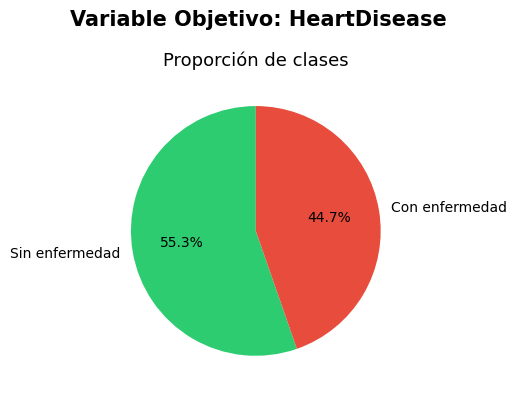

In [82]:
# Distribución de la variable objetivo
plt.figure(figsize=(6, 4))

# Conteo
counts = df['HeartDisease'].value_counts()

# Pie chart
plt.pie(counts.values, labels=['Sin enfermedad', 'Con enfermedad'],
        colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%', startangle=90)

plt.title('Proporción de clases', fontsize=13)
plt.suptitle('Variable Objetivo: HeartDisease', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()



El conjunto de datos presenta una distribución relativamente balanceada, con un 55.3% de pacientes sin enfermedad y un 44.7% con enfermedad cardíaca, lo cual indica que no hay grandes desbalances en esta variable objetivo.

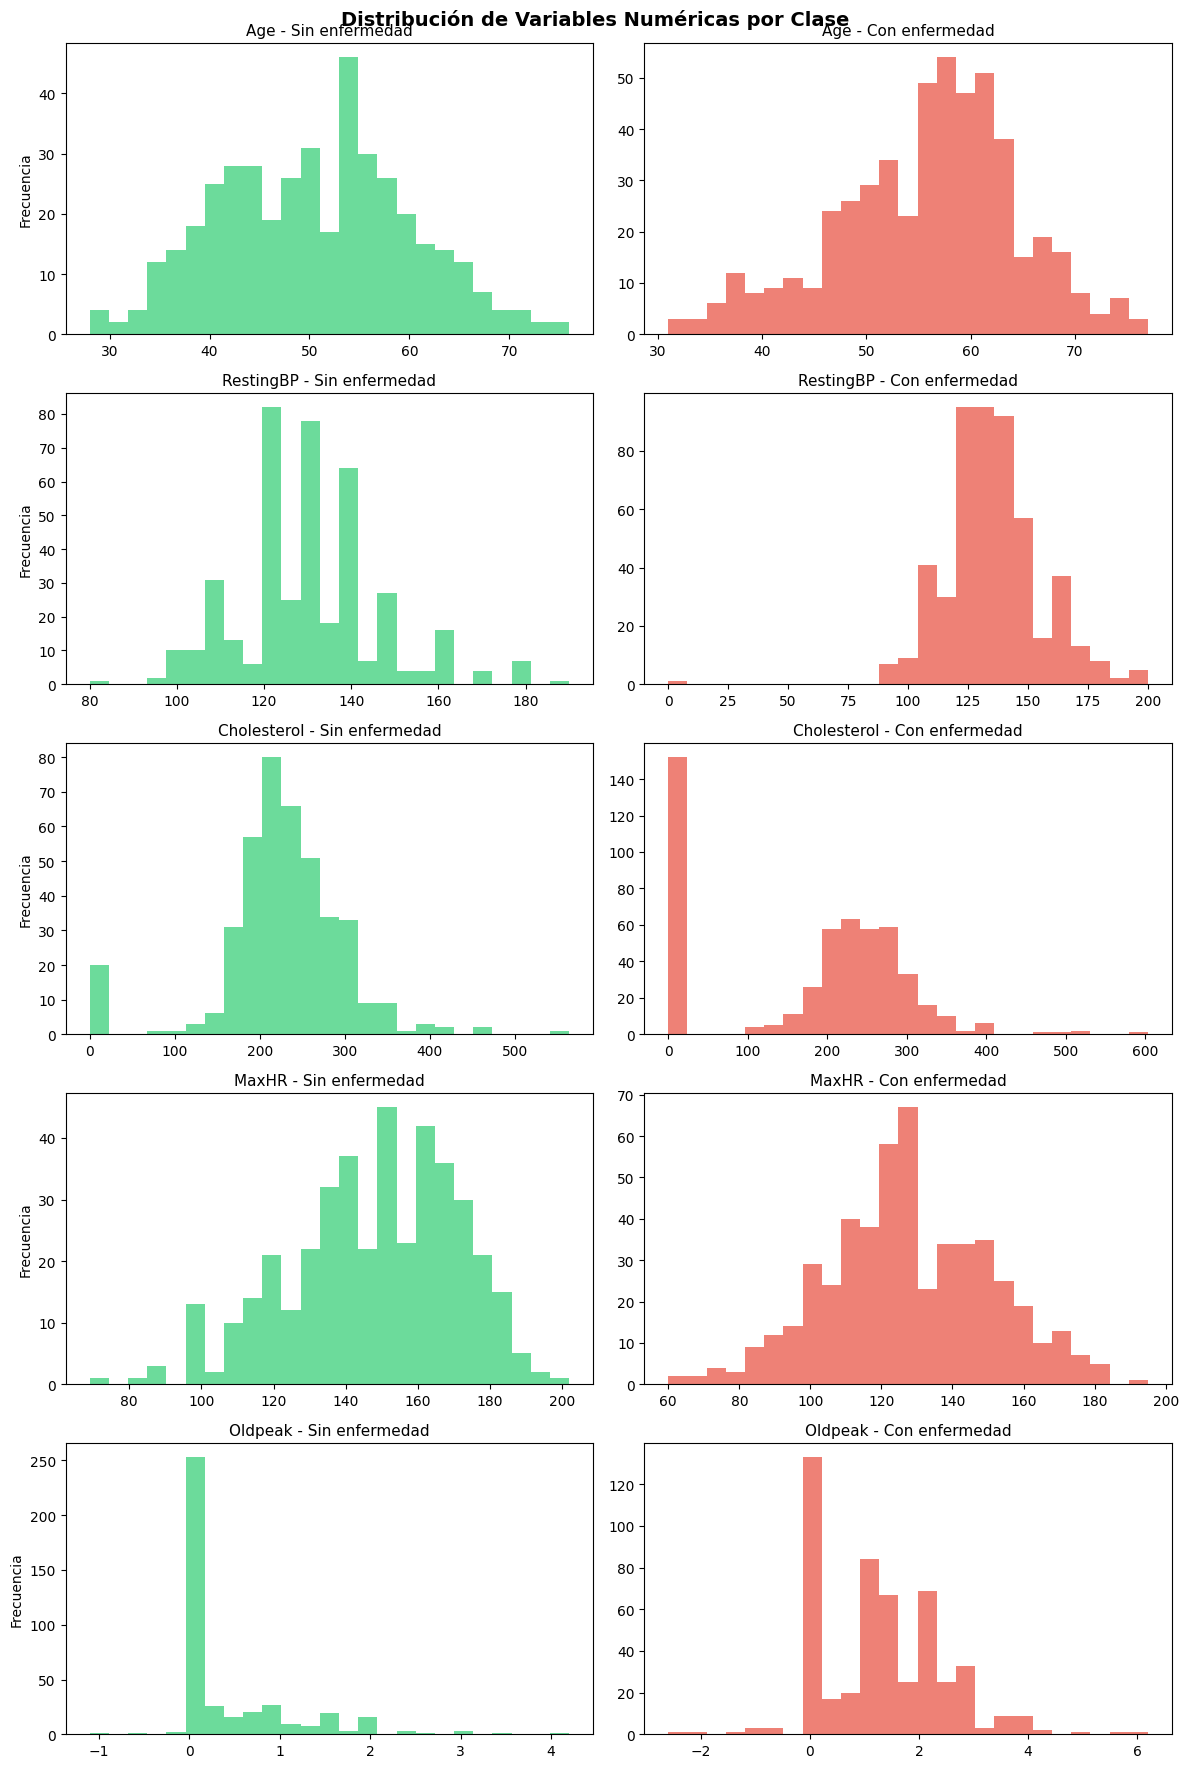

In [83]:
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

fig, axes = plt.subplots(len(num_cols), 2, figsize=(12, 18))

for i, col in enumerate(num_cols):
    
    # Sin enfermedad
    axes[i, 0].hist(df[df['HeartDisease'] == 0][col], bins=25,
                    color='#2ecc71', alpha=0.7)
    axes[i, 0].set_title(f'{col} - Sin enfermedad', fontsize=11)
    axes[i, 0].set_ylabel('Frecuencia')

    # Con enfermedad
    axes[i, 1].hist(df[df['HeartDisease'] == 1][col], bins=25,
                    color='#e74c3c', alpha=0.7)
    axes[i, 1].set_title(f'{col} - Con enfermedad', fontsize=11)

# Ajustes generales
plt.suptitle('Distribución de Variables Numéricas por Clase', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Las distribuciones muestran diferencias  entre clases en varias variables. Los pacientes con enfermedad tienden a concentrarse en edades  mayores y presentan valores de MaxHR más bajos, lo que puede indicar menor capacidad cardiovascular. En Oldpeak, se observan valores más altos en la clase con enfermedad. En RestingBP no presenta una separación muy clara entre clases, mientras que Cholesterol muestra posibles valores atípicos y alta dispersión.

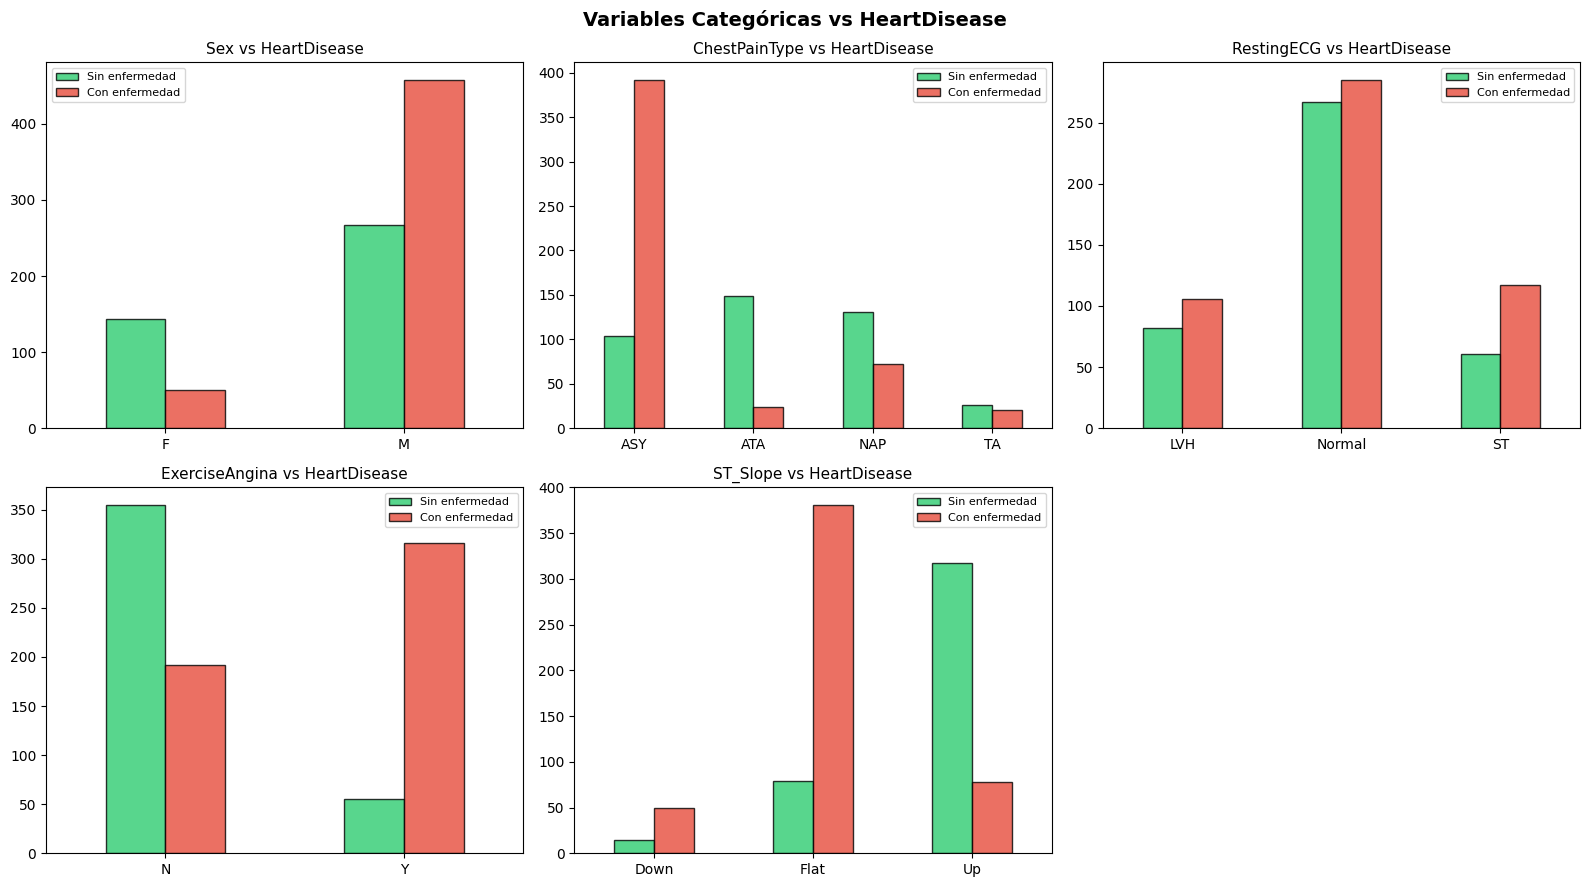

In [84]:
# Análisis de variables categóricas
cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['HeartDisease'])
    ct.plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e74c3c'],
            edgecolor='black', alpha=0.8)
    axes[i].set_title(f'{col} vs HeartDisease', fontsize=11)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(['Sin enfermedad', 'Con enfermedad'], fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Variables Categóricas vs HeartDisease', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Con respecto a las variables categoricas, se observa que el sexo masculino presenta una mayor proporción de casos con enfermedad. El tipo de dolor torácico ASY y la presencia de ExerciseAngina están fuertemente relacionados con la clase positiva. Asimismo, valores como ST_Slope = Flat se asocian más con enfermedad, mientras que Up es más frecuente en pacientes sanos. 

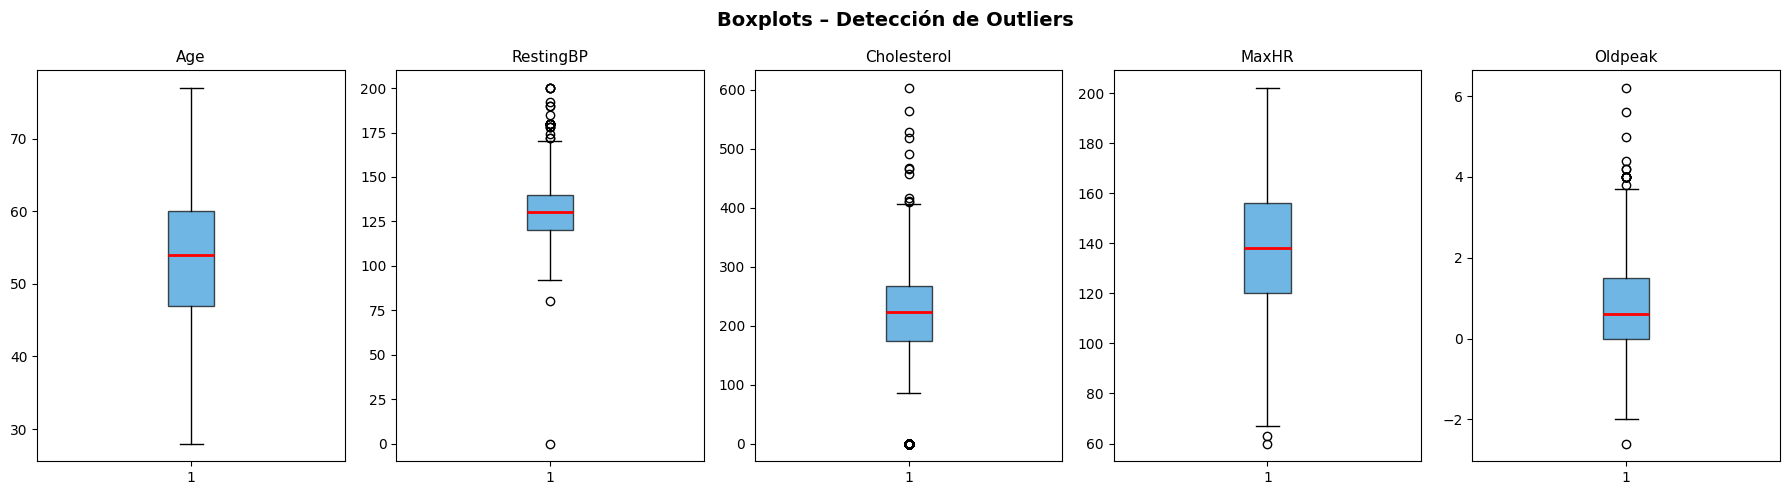

=== OUTLIERS POR MÉTODO IQR ===
  Age: 0 outliers  [límites: 27.5 – 79.5]
  RestingBP: 28 outliers  [límites: 90.0 – 170.0]
  Cholesterol: 183 outliers  [límites: 32.6 – 407.6]
  MaxHR: 2 outliers  [límites: 66.0 – 210.0]
  Oldpeak: 16 outliers  [límites: -2.2 – 3.8]


In [85]:
# Detección de outliers con boxplots
fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 5))

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=11)

plt.suptitle('Boxplots – Detección de Outliers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Reporte de outliers por IQR
print('=== OUTLIERS POR MÉTODO IQR ===')
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f'  {col}: {n_out} outliers  [límites: {lower:.1f} – {upper:.1f}]')

Los boxplots evidencian la presencia de outliers principalmente en Cholesterol, RestingBP y Oldpeak, siendo Cholesterol la variable más afectada con alta dispersión. En cambio, Age y MaxHR presentan pocos o ningún valor atípico, mostrando distribuciones más estables. La existencia de estos outliers sugiere la necesidad de tratar datos para evitar que afecten el rendimiento del modelo.

In [86]:
from scipy.stats import shapiro
# RestingBP
stat_bp, p_bp = shapiro(df['RestingBP'])
print(f"RestingBP -> Estadístico: {stat_bp:.4f}, p-valor: {p_bp:.3e}")

# Cholesterol
stat_chol, p_chol = shapiro(df['Cholesterol'])
print(f"Cholesterol -> Estadístico: {stat_chol:.4f}, p-valor: {p_chol:.3e}")



RestingBP -> Estadístico: 0.9580, p-valor: 1.495e-15
Cholesterol -> Estadístico: 0.8706, p-valor: 6.976e-27


Estas variables no cuentan con distribucion normal, por ende,los valores atipicos se imputaran a traves de la mediana.

In [87]:
# Caso especial: Colesterol = 0 (valor clínicamente imposible)
chol_zeros = (df['Cholesterol'] == 0).sum()
print(f'Registros con Colesterol = 0: {chol_zeros} ({chol_zeros/len(df)*100:.1f}%)')

if chol_zeros > 0:
    # Imputar con la mediana del grupo HeartDisease correspondiente
    mediana_0 = df[df['HeartDisease'] == 0]['Cholesterol'].replace(0, np.nan).median()
    mediana_1 = df[df['HeartDisease'] == 1]['Cholesterol'].replace(0, np.nan).median()
    
    df.loc[(df['Cholesterol'] == 0) & (df['HeartDisease'] == 0), 'Cholesterol'] = mediana_0
    df.loc[(df['Cholesterol'] == 0) & (df['HeartDisease'] == 1), 'Cholesterol'] = mediana_1
    print(f'✅ Colesterol=0 imputado con mediana por grupo (clase 0: {mediana_0:.0f}, clase 1: {mediana_1:.0f})')

# Verificar RestingBP = 0 también
bp_zeros = (df['RestingBP'] == 0).sum()
print(f'Registros con RestingBP = 0: {bp_zeros}')
if bp_zeros > 0:
    df['RestingBP'] = df['RestingBP'].replace(0, df['RestingBP'].replace(0, np.nan).median())
    print(f'✅ RestingBP=0 imputado con la mediana general')

Registros con Colesterol = 0: 172 (18.7%)
✅ Colesterol=0 imputado con mediana por grupo (clase 0: 232, clase 1: 246)
Registros con RestingBP = 0: 1
✅ RestingBP=0 imputado con la mediana general


Ante valores clinicos imposibles, se identificaron valores inválidos en Cholesterol = 0 . Los cuales fueron imputados utilizando la mediana por clase de la variable objetivo, debido a que la distribucion no es normal, evitanso sesgos y preservando así diferencias entre pacientes con y sin enfermedad. De la misma manera, para RestingBP se detectó un único valor en cero, que fue reemplazado por la mediana .

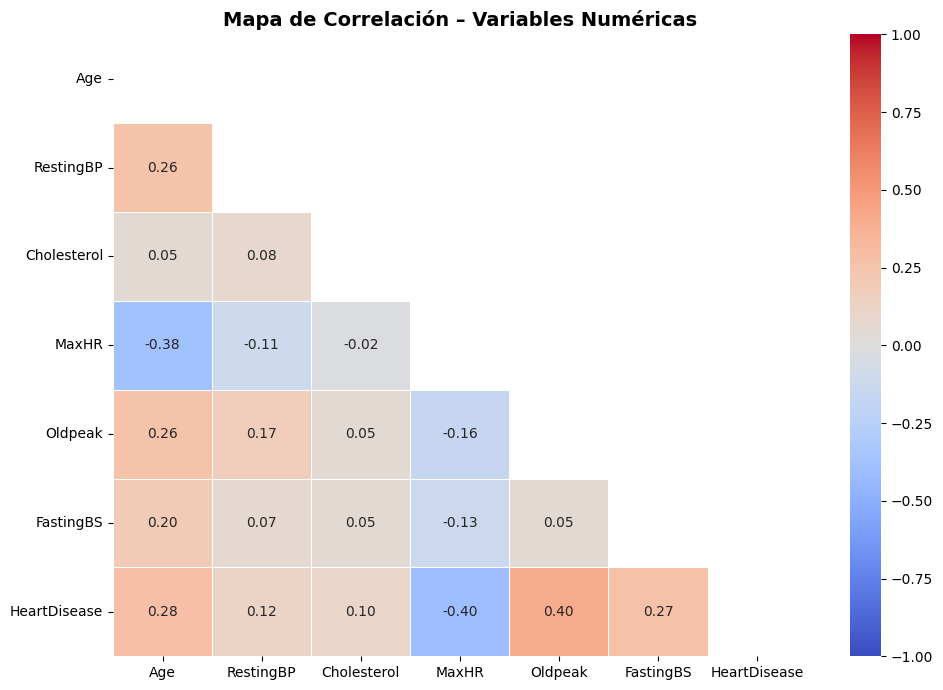

In [88]:
# Mapa de correlación (variables numéricas)
plt.figure(figsize=(10, 7))
corr = df[num_cols + ['FastingBS', 'HeartDisease']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Mapa de Correlación – Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

El mapa de correlación muestra relaciones  bajas entre las variables numéricas, lo que muestra ausencia de multicolinealidad . Sin embargo, existen correlaciones moderadas con la variable objetivo como Oldpeak con 0.40 y Age con 0.28, teniendo correlación positiva con la enfermedad. Mientras que MaxHR con -0.40 presenta una relación negativa.

## 3. Preprocesamiento: Identificación de Columnas

A continuacion , separamos las variables entre  categoricas y numericas

In [89]:
# ──────────────────────────────────────────────────────────────────
# Codificación con OrdinalEncoder DENTRO del Pipeline (sin dummies)
# ──────────────────────────────────────────────────────────────────
# Las variables categóricas serán codificadas SOLO con los datos de
# entrenamiento gracias al ColumnTransformer dentro del Pipeline.
# Esto evita data leakage y no genera columnas extra (sin explosión
# de dimensionalidad propia del One-Hot Encoding).

cat_features = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
num_features = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']

print('Variables categóricas:', cat_features)
print('Variables numéricas:  ', num_features)
print()
print('Valores únicos por categoría:')
for col in cat_features:
    print(f'  {col}: {sorted(df[col].unique().tolist())}')

Variables categóricas: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
Variables numéricas:   ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']

Valores únicos por categoría:
  Sex: ['F', 'M']
  ChestPainType: ['ASY', 'ATA', 'NAP', 'TA']
  RestingECG: ['LVH', 'Normal', 'ST']
  ExerciseAngina: ['N', 'Y']
  ST_Slope: ['Down', 'Flat', 'Up']


Se realiza la separación del conjunto de datos en variables predictoras (X) y la variable objetivo (y).

In [90]:
# Separacion de features y target 
X = df[cat_features + num_features].copy()
y = df['HeartDisease'].copy()

print(f'Features (X): {X.shape}  – {X.shape[1]} columnas  ')
print(f'Target  (y): {y.shape}')


Features (X): (918, 11)  – 11 columnas  
Target  (y): (918,)


## 4. Demostración de Data Leakage

A continuacion, realizamos el procesamiento incorrecto implementando escalado y la codificación se ajustan sobre todo el dataset antes de dividir en entrenamiento y prueba, generando data leakage


In [91]:

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder

X_leak = X.copy()
X_leak['leaky_feature'] = y.values + np.random.normal(0, 0.01, size=len(y))

cat_leak = cat_features
num_leak = num_features + ['leaky_feature']

preproc_leak = ColumnTransformer([
    ('cat', OrdinalEncoder(), cat_leak),
    ('num', MinMaxScaler(),   num_leak)
])
X_scaled_leak = preproc_leak.fit_transform(X_leak) 

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_scaled_leak, y, test_size=0.2, random_state=SEED)

grid_leak = GridSearchCV(
    SVC(probability=True),
    param_grid={'C': [0.1, 1, 10], 'gamma': [0.01, 0.1]},
    cv=5,
    scoring='roc_auc',
    n_jobs=1
)
grid_leak.fit(X_train_l, y_train_l)
auc_leak = roc_auc_score(y_test_l, grid_leak.predict_proba(X_test_l)[:, 1])
acc_leak = accuracy_score(y_test_l, grid_leak.predict(X_test_l))

print('  FLUJO INCORRECTO :')
print(f'   AUC:      {auc_leak:.4f}')
print(f'   Accuracy: {acc_leak:.4f}')

  FLUJO INCORRECTO :
   AUC:      1.0000
   Accuracy: 1.0000


Se observa un AUC y accuracy de 1, lo que indica supuestamente que el modelo es completamente perfecto, pero esto no refleja la verdadera capacidad del modelo por presencia de data leakage.


## 5. División Train / Test Estratificada

A continuacion aplicamos el flujo correcto de modelado, donde primero se realiza una división estratificada para conservar la proporción de clases en entrenamiento y prueba. Luego, el preprocesamiento se integra dentro de un Pipeline, asegurando que el modelo solo aprenda a partir de los datos de entrenamiento y evitando data leakage.

In [92]:
# ✅ División PRIMERO – stratify garantiza misma proporción en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y          # crucial para datasets desbalanceados
)

print(' DIVISIÓN ESTRATIFICADA ')
print(f'Train : {X_train.shape[0]} muestras')
print(f'Test  : {X_test.shape[0]} muestras')
print()

prop_total = y.mean()
prop_train = y_train.mean()
prop_test  = y_test.mean()
print(f'Proporción clase 1  – Total: {prop_total:.3f} | Train: {prop_train:.3f} | Test: {prop_test:.3f}')


 DIVISIÓN ESTRATIFICADA 
Train : 734 muestras
Test  : 184 muestras

Proporción clase 1  – Total: 0.553 | Train: 0.553 | Test: 0.554


Se realiza la división estratificada de los datos en entrenamiento y prueba. Su propósito es asegurar que ambos conjuntos mantengan una proporción similar de la clase objetivo

## 6. Comparación de Múltiples Clasificadores con Pipeline + GridSearchCV

Se define la validación cruzada estratificada de 5 pliegues para mantener el balance de clases en cada partición. Luego, se especifican varios modelos de clasificación como SVM, Regresión Logística, Random Forest, KNN y Gradient Boosting junto con sus hiperparámetros. Lo cual permite optimizar y comparar el desempeño de cada modelo mediante GridSearchCV.

In [93]:
# Esquema de validación cruzada estratificada (5 pliegues)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

modelos = [
    {
        'nombre': 'SVC',
        'modelo': SVC(probability=True, random_state=SEED),
        'param_grid': {
            'clf__C':      [0.1, 1, 10, 100],
            'clf__gamma':  [0.001, 0.01, 0.1, 1],
            'clf__kernel': ['rbf', 'linear']
        }
    },
    {
        'nombre': 'LogisticRegression',
        'modelo': LogisticRegression(max_iter=1000, random_state=SEED),
        'param_grid': {
            'clf__C':      [0.01, 0.1, 1, 10, 100],
            'clf__solver': ['lbfgs', 'liblinear'],
            'clf__penalty':['l2']
        }
    },
    {
        'nombre': 'RandomForest',
        'modelo': RandomForestClassifier(random_state=SEED),
        'param_grid': {
            'clf__n_estimators':      [100, 200],
            'clf__max_depth':         [None, 5, 10],
            'clf__max_features':      ['sqrt', 'log2'],
            'clf__min_samples_split': [2, 5]
        }
    },
    {
        'nombre': 'KNeighbors',
        'modelo': KNeighborsClassifier(),
        'param_grid': {
            'clf__n_neighbors': [3, 5, 7, 9, 11],
            'clf__weights':     ['uniform', 'distance'],
            'clf__metric':      ['euclidean', 'manhattan']
        }
    },
    {
        'nombre': 'GradientBoosting',
        'modelo': GradientBoostingClassifier(random_state=SEED),
        'param_grid': {
            'clf__n_estimators':  [100, 200],
            'clf__learning_rate': [0.05, 0.1, 0.2],
            'clf__max_depth':     [3, 5]
        }
    }
]



Se va a construir un pipeline que integra el preprocesamiento como la codificación y escalado con cada modelo, optimizado mediante GridSearchCV con validación cruzada. Luego, se entrenan múltiples modelos y se generan predicciones sobre el conjunto de prueba.

In [94]:
def build_preprocessor():
    """ColumnTransformer: OrdinalEncoder para cat + MinMaxScaler para num."""
    return ColumnTransformer([
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_features),
        ('num', MinMaxScaler(), num_features)
    ])

def entrenar_pipeline(X_train, y_train, modelo, param_grid, cv):
    """Construye Pipeline(ColumnTransformer + modelo) y ajusta con GridSearchCV."""
    pipe = Pipeline([
        ('preprocessor', build_preprocessor()),
        ('clf', modelo)
    ])
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=cv,
        scoring='roc_auc',
        n_jobs=1,
        refit=True
    )
    grid.fit(X_train, y_train)
    return grid


resultados = []
grids_entrenados = {}

for m in modelos:
    print(f'⏳ {m["nombre"]:22s} ...', end=' ', flush=True)
    grid = entrenar_pipeline(X_train, y_train, m['modelo'], m['param_grid'], skf)
    grids_entrenados[m['nombre']] = grid

    y_pred = grid.predict(X_test)
    y_proba = grid.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    cv_auc = cross_val_score(
        grid.best_estimator_, X_train, y_train,
        cv=skf, scoring='roc_auc', n_jobs=1
    )
    cv_f1 = cross_val_score(
        grid.best_estimator_, X_train, y_train,
        cv=skf, scoring='f1', n_jobs=1
    )
    cv_acc = cross_val_score(
        grid.best_estimator_, X_train, y_train,
        cv=skf, scoring='accuracy', n_jobs=1
    )

    resultados.append({
        'Modelo': m['nombre'],
        'AUC_test': round(auc, 4),
        'Accuracy_test': round(acc, 4),
        'F1_test': round(f1, 4),
        'CV_AUC_mean': round(cv_auc.mean(), 4),
        'CV_AUC_std': round(cv_auc.std(), 4),
        'CV_F1_mean': round(cv_f1.mean(), 4),
        'CV_F1_std': round(cv_f1.std(), 4),
        'CV_Acc_mean': round(cv_acc.mean(), 4),
        'CV_Acc_std': round(cv_acc.std(), 4),
        'Best_params': grid.best_params_
    })
    print(f'AUC={auc:.4f}  F1={f1:.4f}  CV_AUC={cv_auc.mean():.4f}±{cv_auc.std():.4f}')


⏳ SVC                    ... AUC=0.8833  F1=0.8374  CV_AUC=0.9167±0.0390
⏳ LogisticRegression     ... AUC=0.9010  F1=0.8654  CV_AUC=0.9143±0.0353
⏳ RandomForest           ... AUC=0.9421  F1=0.9179  CV_AUC=0.9375±0.0246
⏳ KNeighbors             ... AUC=0.9279  F1=0.9143  CV_AUC=0.9127±0.0363
⏳ GradientBoosting       ... AUC=0.9486  F1=0.9179  CV_AUC=0.9357±0.0153


Los resultados muestran que los modelos con mejor desempeño son Gradient Boosting con AUC=0.9486 y Random Forest con AUC=0.9421, ambos con altos valores de F1 0.9179. KNN también presenta buen rendimiento, mientras que SVC y Regresión Logística tienen métricas ligeramente inferiores pero consistentes. Además, las métricas de validación cruzada son estables, lo que indica buena capacidad de generalización y poco sobreajuste.

---
## 7. Ranking Comparativo de Modelos

In [95]:
df_res = (pd.DataFrame(resultados)
            .sort_values('AUC_test', ascending=False)
            .reset_index(drop=True))
df_res.index += 1
df_res.index.name = 'Rank'

cols_show = ['Modelo','AUC_test','Accuracy_test','F1_test',
             'CV_AUC_mean','CV_AUC_std','CV_F1_mean','CV_F1_std']
print('=== 🏆 RANKING FINAL ===')
print(df_res[cols_show].to_string())

=== 🏆 RANKING FINAL ===
                  Modelo  AUC_test  Accuracy_test  F1_test  CV_AUC_mean  CV_AUC_std  CV_F1_mean  CV_F1_std
Rank                                                                                                      
1       GradientBoosting    0.9486         0.9076   0.9179       0.9357      0.0153      0.8825     0.0160
2           RandomForest    0.9421         0.9076   0.9179       0.9375      0.0246      0.8734     0.0254
3             KNeighbors    0.9279         0.9022   0.9143       0.9127      0.0363      0.8700     0.0261
4     LogisticRegression    0.9010         0.8478   0.8654       0.9143      0.0353      0.8547     0.0240
5                    SVC    0.8833         0.8207   0.8374       0.9167      0.0390      0.8568     0.0192


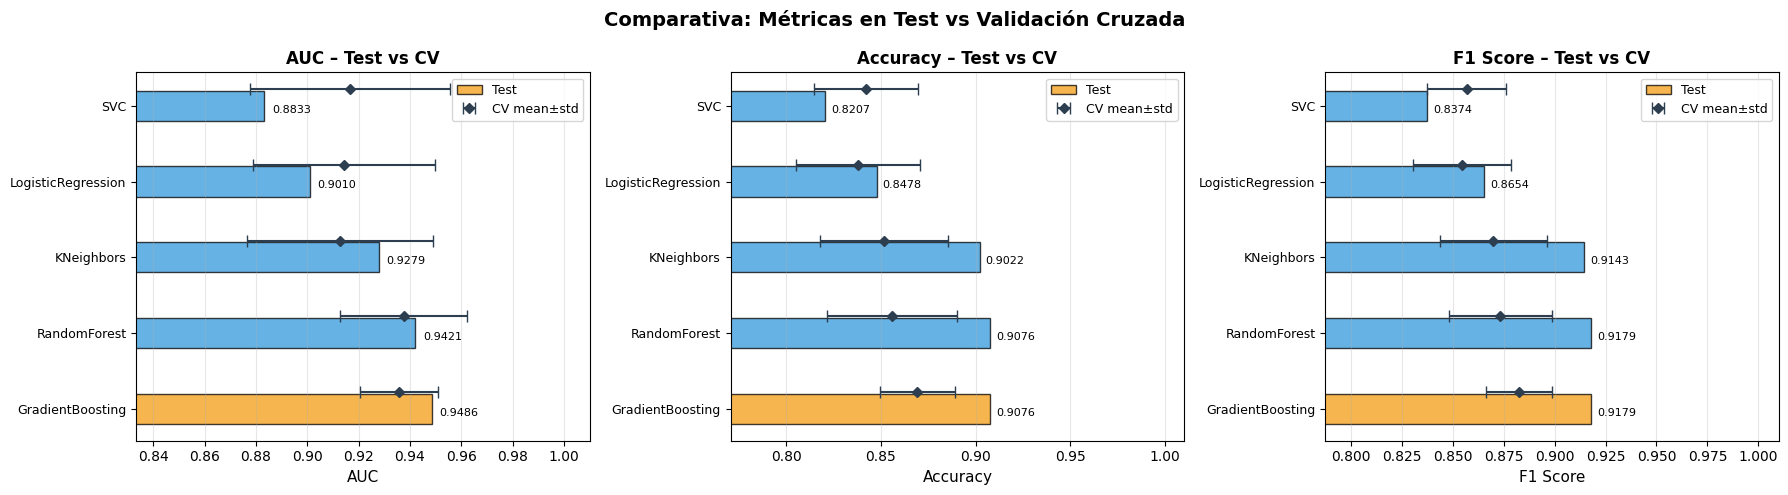

In [96]:
# Gráfico comparativo: Test vs CV con barras de error
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colores   = ['#f39c12' if i == 0 else '#3498db' for i in range(len(df_res))]

for ax, (col_test, col_cv_m, col_cv_s, titulo) in zip(axes, [
    ('AUC_test',      'CV_AUC_mean', 'CV_AUC_std', 'AUC'),
    ('Accuracy_test', 'CV_Acc_mean', 'CV_Acc_std', 'Accuracy'),
    ('F1_test',       'CV_F1_mean',  'CV_F1_std',  'F1 Score'),
]):
    y_pos = range(len(df_res))
    # Barra test
    ax.barh(y_pos, df_res[col_test], color=colores,
            edgecolor='black', alpha=0.75, label='Test', height=0.4)
    # Punto CV con error
    ax.errorbar(df_res[col_cv_m], [p + 0.22 for p in y_pos],
                xerr=df_res[col_cv_s], fmt='D', color='#2c3e50',
                markersize=5, capsize=4, label='CV mean±std', zorder=5)
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(df_res['Modelo'], fontsize=9)
    ax.set_xlabel(titulo, fontsize=11)
    ax.set_title(f'{titulo} – Test vs CV', fontsize=12, fontweight='bold')
    ax.set_xlim([df_res[col_test].min() - 0.05, 1.01])
    ax.legend(fontsize=9)
    ax.grid(axis='x', alpha=0.3)
    # Etiquetas
    for p, val in zip(y_pos, df_res[col_test]):
        ax.text(val + 0.003, p - 0.05, f'{val:.4f}', va='center', fontsize=8)

plt.suptitle('Comparativa: Métricas en Test vs Validación Cruzada',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Las métricas en test son consistentes con las obtenidas en validación cruzada. Los modelos Gradient Boosting y Random Forest destacan con los mejores valores en AUC, Accuracy y F1, manteniendo estabilidad (baja desviación). No se observan diferencias grandes entre CV y test, lo que sugiere ausencia de sobreajuste significativo.

---
## 8. Matrices de Confusión – Todos los Modelos

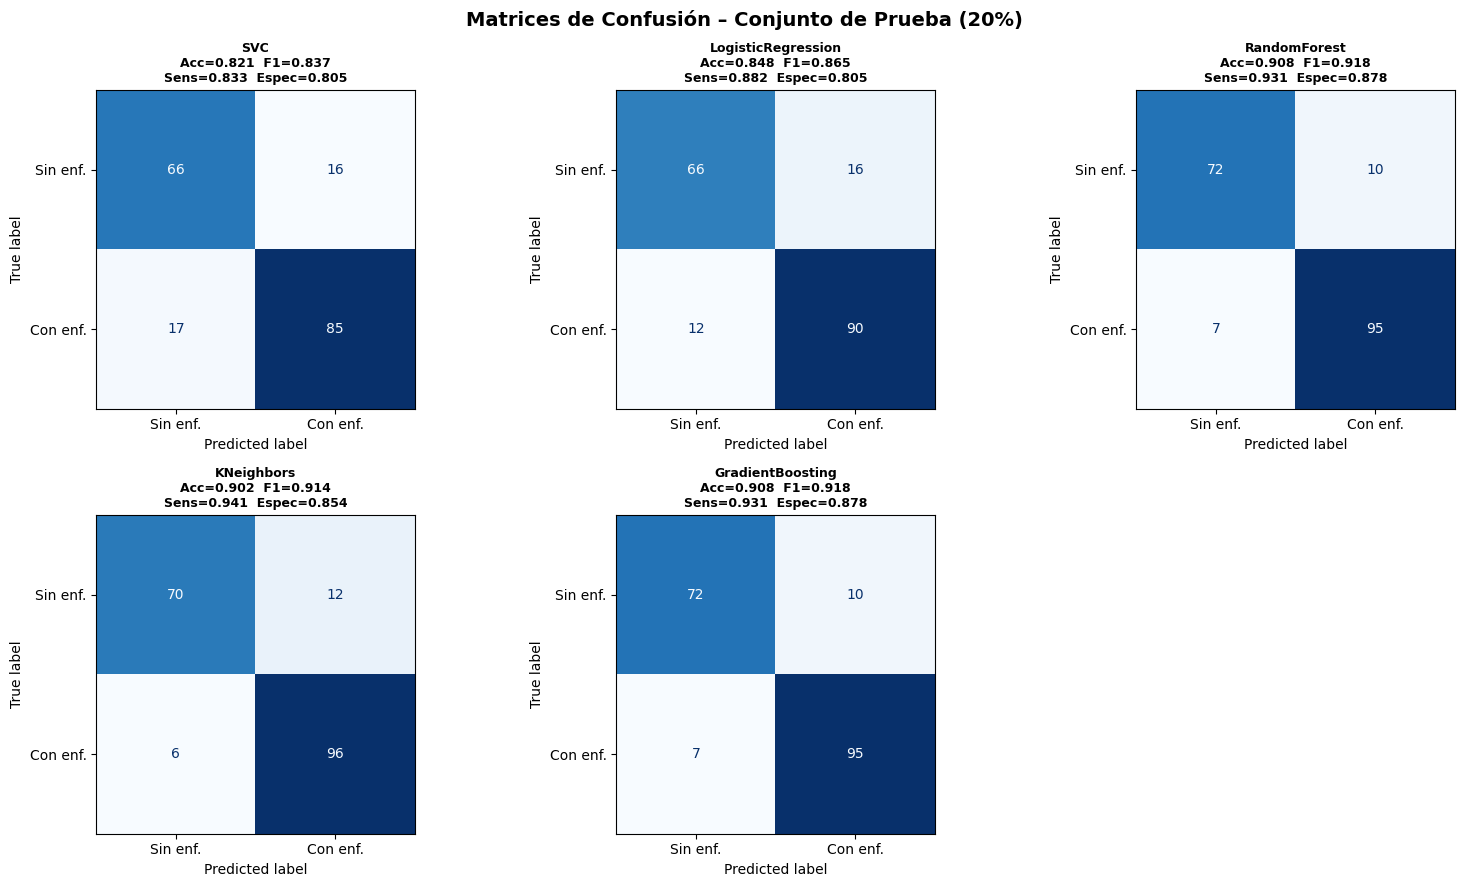

=== TABLA DE TP / FP / TN / FN ===
Modelo                    TP    FP    TN    FN    Sens   Espec
------------------------------------------------------------
SVC                       85    16    66    17   0.833   0.805
LogisticRegression        90    16    66    12   0.882   0.805
RandomForest              95    10    72     7   0.931   0.878
KNeighbors                96    12    70     6   0.941   0.854
GradientBoosting          95    10    72     7   0.931   0.878


In [97]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (nombre, grid) in enumerate(grids_entrenados.items()):
    y_pred = grid.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    f1     = f1_score(y_test, y_pred)
    acc    = accuracy_score(y_test, y_pred)

    # Calcular métricas desde la matriz
    tn, fp, fn, tp = cm.ravel()
    sensibilidad   = tp / (tp + fn)   # Recall clase 1
    especificidad  = tn / (tn + fp)   # Recall clase 0

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Sin enf.', 'Con enf.'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(
        f'{nombre}\n'
        f'Acc={acc:.3f}  F1={f1:.3f}\n'
        f'Sens={sensibilidad:.3f}  Espec={especificidad:.3f}',
        fontsize=9, fontweight='bold'
    )

axes[-1].set_visible(False)
plt.suptitle('Matrices de Confusión – Conjunto de Prueba (20%)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabla de TP, FP, TN, FN
print('=== TABLA DE TP / FP / TN / FN ===')
print(f'{"Modelo":<22} {"TP":>5} {"FP":>5} {"TN":>5} {"FN":>5} {"Sens":>7} {"Espec":>7}')
print('-' * 60)
for nombre, grid in grids_entrenados.items():
    y_pred = grid.predict(X_test)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    sens  = tp / (tp + fn)
    espec = tn / (tn + fp)
    print(f'{nombre:<22} {tp:>5} {fp:>5} {tn:>5} {fn:>5} {sens:>7.3f} {espec:>7.3f}')

---
## 9. Curvas ROC y Precisión-Recall – Todos los Modelos

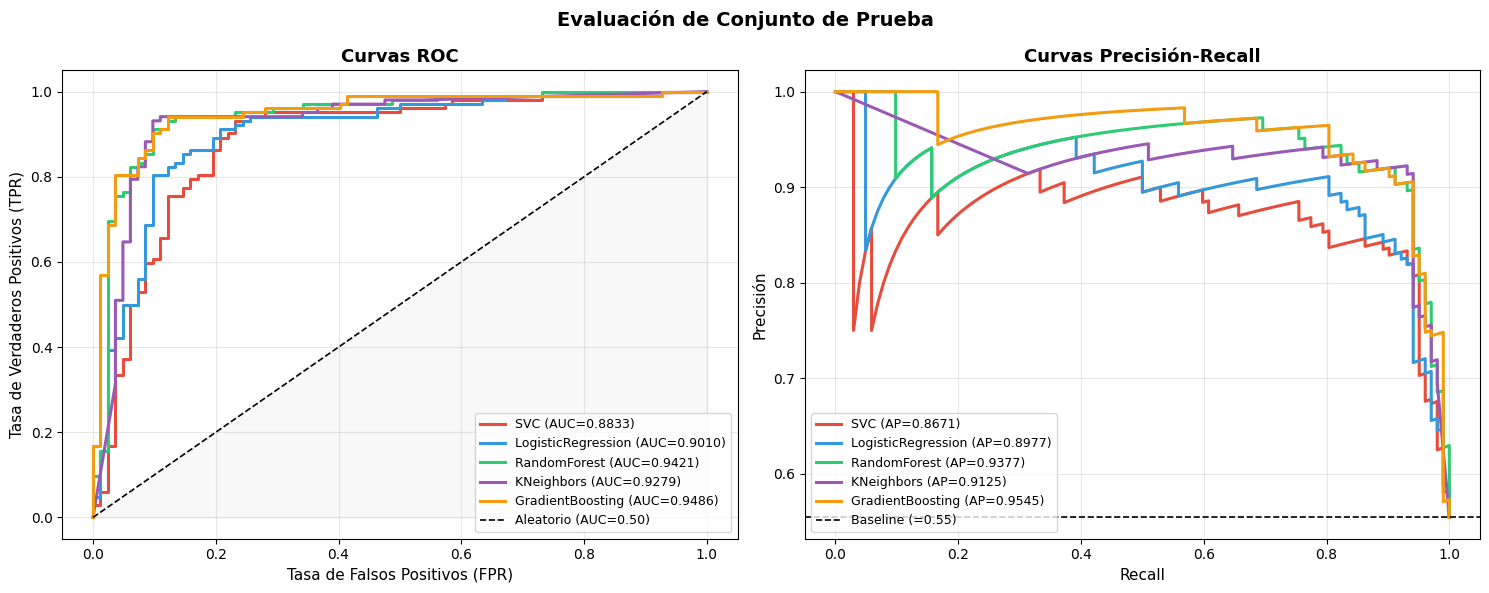

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

colores_roc = ['#e74c3c','#3498db','#2ecc71','#9b59b6','#f39c12']

# --- Curva ROC ---
for (nombre, grid), color in zip(grids_entrenados.items(), colores_roc):
    y_proba = grid.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[0].plot(fpr, tpr, color=color, linewidth=2.2,
                 label=f'{nombre} (AUC={auc:.4f})')

axes[0].plot([0,1],[0,1],'k--', linewidth=1.2, label='Aleatorio (AUC=0.50)')
axes[0].fill_between([0,1],[0,1], alpha=0.05, color='gray')
axes[0].set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
axes[0].set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
axes[0].set_title('Curvas ROC', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(alpha=0.3)

# --- Curva Precision-Recall ---
for (nombre, grid), color in zip(grids_entrenados.items(), colores_roc):
    y_proba = grid.predict_proba(X_test)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    axes[1].plot(rec, prec, color=color, linewidth=2.2,
                 label=f'{nombre} (AP={ap:.4f})')

baseline = y_test.mean()
axes[1].axhline(baseline, color='k', linestyle='--', linewidth=1.2,
                label=f'Baseline (={baseline:.2f})')
axes[1].set_xlabel('Recall', fontsize=11)
axes[1].set_ylabel('Precisión', fontsize=11)
axes[1].set_title('Curvas Precisión-Recall', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower left', fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle('Evaluación de Conjunto de Prueba',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Las curvas ROC muestran que Gradient Boosting y Random Forest tienen la mejor capacidad de clasificacion, con AUC más altos y cercanos a 1. En las curvas Precision-Recall, estos mismos modelos mantienen mayor precisión a lo largo de distintos niveles de recall.

## 10. Validación Cruzada Detallada – Boxplots por Pliegue

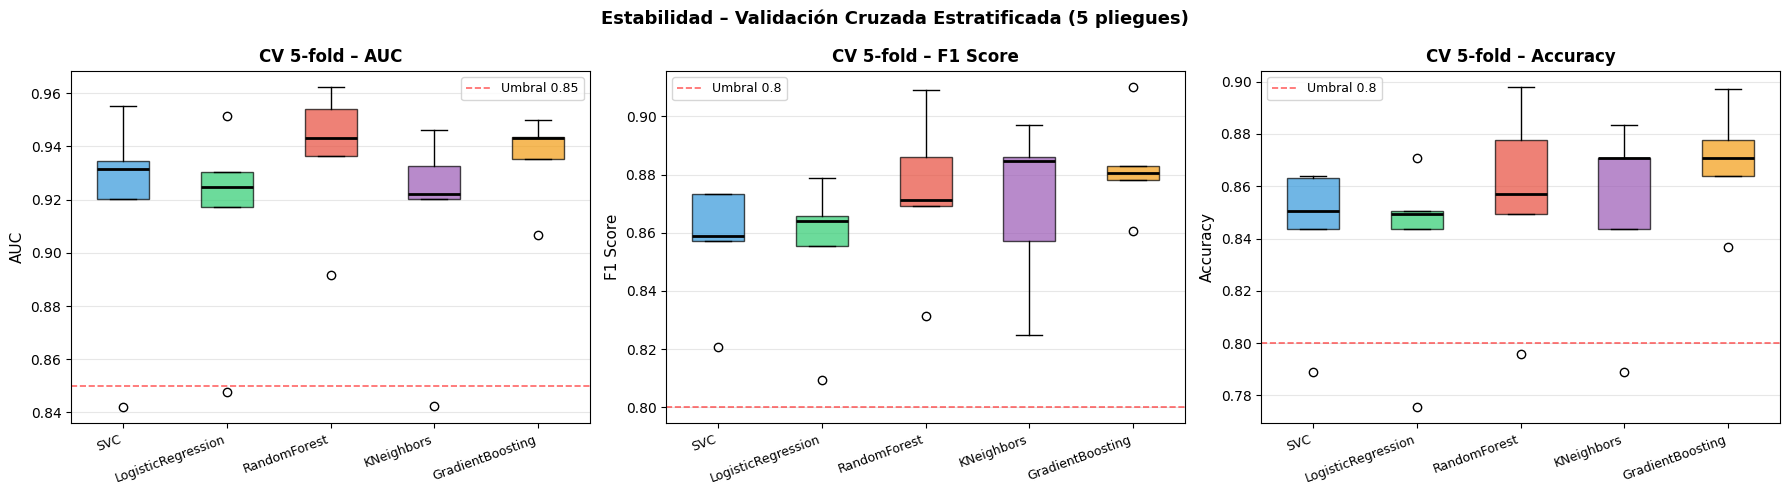


=== RESUMEN DE VALIDACIÓN CRUZADA ===
Modelo                     AUC mean±std     F1 mean±std    Acc mean±std
------------------------------------------------------------------------
SVC                    0.9167 ± 0.0390   0.8568 ± 0.0192   0.8420 ± 0.0275
LogisticRegression     0.9143 ± 0.0353   0.8547 ± 0.0240   0.8379 ± 0.0325
RandomForest           0.9375 ± 0.0246   0.8734 ± 0.0254   0.8556 ± 0.0343
KNeighbors             0.9127 ± 0.0363   0.8700 ± 0.0261   0.8515 ± 0.0338
GradientBoosting       0.9357 ± 0.0153   0.8825 ± 0.0160   0.8692 ± 0.0197


In [99]:
# Recopilar scores por pliegue para cada modelo
cv_data_auc = {}
cv_data_f1  = {}
cv_data_acc = {}

for nombre, grid in grids_entrenados.items():
    cv_data_auc[nombre] = cross_val_score(
        grid.best_estimator_, X_train, y_train, cv=skf, scoring='roc_auc', n_jobs=1)
    cv_data_f1[nombre]  = cross_val_score(
        grid.best_estimator_, X_train, y_train, cv=skf, scoring='f1',      n_jobs=1)
    cv_data_acc[nombre] = cross_val_score(
        grid.best_estimator_, X_train, y_train, cv=skf, scoring='accuracy',n_jobs=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colores_box = ['#3498db','#2ecc71','#e74c3c','#9b59b6','#f39c12']

for ax, data, titulo, umbral in [
    (axes[0], cv_data_auc, 'AUC',      0.85),
    (axes[1], cv_data_f1,  'F1 Score', 0.80),
    (axes[2], cv_data_acc, 'Accuracy', 0.80),
]:
    bp = ax.boxplot(data.values(), patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2))
    ax.set_xticklabels(data.keys(), rotation=20, ha='right', fontsize=9)
    ax.set_ylabel(titulo, fontsize=11)
    ax.set_title(f'CV 5-fold – {titulo}', fontsize=12, fontweight='bold')
    ax.axhline(umbral, color='red', linestyle='--', linewidth=1.2,
               alpha=0.6, label=f'Umbral {umbral}')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    for patch, color in zip(bp['boxes'], colores_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

plt.suptitle('Estabilidad – Validación Cruzada Estratificada (5 pliegues)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabla de resumen
print('\n=== RESUMEN DE VALIDACIÓN CRUZADA ===')
print(f'{"Modelo":<22} {"AUC mean±std":>16} {"F1 mean±std":>15} {"Acc mean±std":>15}')
print('-' * 72)
for nombre in cv_data_auc:
    a_m, a_s = cv_data_auc[nombre].mean(), cv_data_auc[nombre].std()
    f_m, f_s = cv_data_f1[nombre].mean(),  cv_data_f1[nombre].std()
    c_m, c_s = cv_data_acc[nombre].mean(), cv_data_acc[nombre].std()
    print(f'{nombre:<22} {a_m:.4f} ± {a_s:.4f}   {f_m:.4f} ± {f_s:.4f}   {c_m:.4f} ± {c_s:.4f}')

Se observa que Gradient Boosting y Random Forest tienen medianas más altas y menor variabilidad, lo que indica modelos más estables y consistentes. Mientras que el modelo de KNN presenta mayor dispersión, lo que indica que su rendimiento depende más de la partición de los datos.

## 11. Curvas de Aprendizaje – Mejor Modelo



🏆 Mejor modelo: GradientBoosting
   Parámetros: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 100}


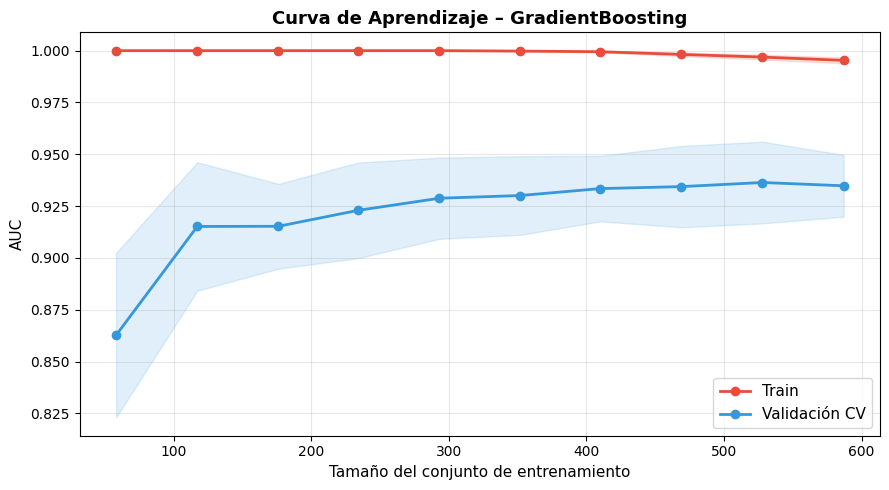

In [100]:
mejor_nombre = df_res.iloc[0]['Modelo']
mejor_grid   = grids_entrenados[mejor_nombre]

print(f'🏆 Mejor modelo: {mejor_nombre}')
print(f'   Parámetros: {mejor_grid.best_params_}')

# Curva de aprendizaje
train_sizes, train_scores, val_scores = learning_curve(
    mejor_grid.best_estimator_,
    X_train, y_train,
    cv=skf,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_mean, 'o-', color='#e74c3c', linewidth=2, label='Train')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color='#e74c3c')
ax.plot(train_sizes, val_mean, 'o-', color='#3498db', linewidth=2, label='Validación CV')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color='#3498db')
ax.set_xlabel('Tamaño del conjunto de entrenamiento', fontsize=11)
ax.set_ylabel('AUC', fontsize=11)
ax.set_title(f'Curva de Aprendizaje – {mejor_nombre}', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

La gráfica muestra que el modelo alcanza un rendimiento perfecto en entrenamiento alrededor de 1.000, lo que indica alta capacidad de ajuste. Sin embargo, la curva de validación se mantiene ligeramente por debajo, evidenciando un pequeño sobreajuste. Aun así, la estabilidad de la curva sugiere buena capacidad de procesar datos nuevos para predeir.


## 12. Reporte Final del Mejor Modelo

In [101]:
y_pred_best  = mejor_grid.predict(X_test)
y_proba_best = mejor_grid.predict_proba(X_test)[:, 1]

auc_best = roc_auc_score(y_test, y_proba_best)
acc_best = accuracy_score(y_test, y_pred_best)
f1_best  = f1_score(y_test, y_pred_best)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_best).ravel()

print(f'╔══════════════════════════════════════════════╗')
print(f'║  REPORTE FINAL – {mejor_nombre:<27} ║')
print(f'╠══════════════════════════════════════════════╣')
print(f'║  AUC (Test)            : {auc_best:.4f}              ║')
print(f'║  Accuracy (Test)       : {acc_best:.4f}              ║')
print(f'║  F1 Score  (Test)      : {f1_best:.4f}              ║')
print(f'║  Sensibilidad (Recall) : {tp/(tp+fn):.4f}              ║')
print(f'║  Especificidad         : {tn/(tn+fp):.4f}              ║')
print(f'║  Precisión             : {tp/(tp+fp):.4f}              ║')
print(f'╠══════════════════════════════════════════════╣')
print(f'║  CV AUC mean±std  : {df_res.iloc[0]["CV_AUC_mean"]:.4f} ± {df_res.iloc[0]["CV_AUC_std"]:.4f}          ║')
print(f'║  CV F1  mean±std  : {df_res.iloc[0]["CV_F1_mean"]:.4f} ± {df_res.iloc[0]["CV_F1_std"]:.4f}          ║')
print(f'╚══════════════════════════════════════════════╝')
print()
print('=== CLASSIFICATION REPORT ===')
print(classification_report(y_test, y_pred_best,
                             target_names=['Sin enfermedad','Con enfermedad']))

╔══════════════════════════════════════════════╗
║  REPORTE FINAL – GradientBoosting            ║
╠══════════════════════════════════════════════╣
║  AUC (Test)            : 0.9486              ║
║  Accuracy (Test)       : 0.9076              ║
║  F1 Score  (Test)      : 0.9179              ║
║  Sensibilidad (Recall) : 0.9314              ║
║  Especificidad         : 0.8780              ║
║  Precisión             : 0.9048              ║
╠══════════════════════════════════════════════╣
║  CV AUC mean±std  : 0.9357 ± 0.0153          ║
║  CV F1  mean±std  : 0.8825 ± 0.0160          ║
╚══════════════════════════════════════════════╝

=== CLASSIFICATION REPORT ===
                precision    recall  f1-score   support

Sin enfermedad       0.91      0.88      0.89        82
Con enfermedad       0.90      0.93      0.92       102

      accuracy                           0.91       184
     macro avg       0.91      0.90      0.91       184
  weighted avg       0.91      0.91      0.91     

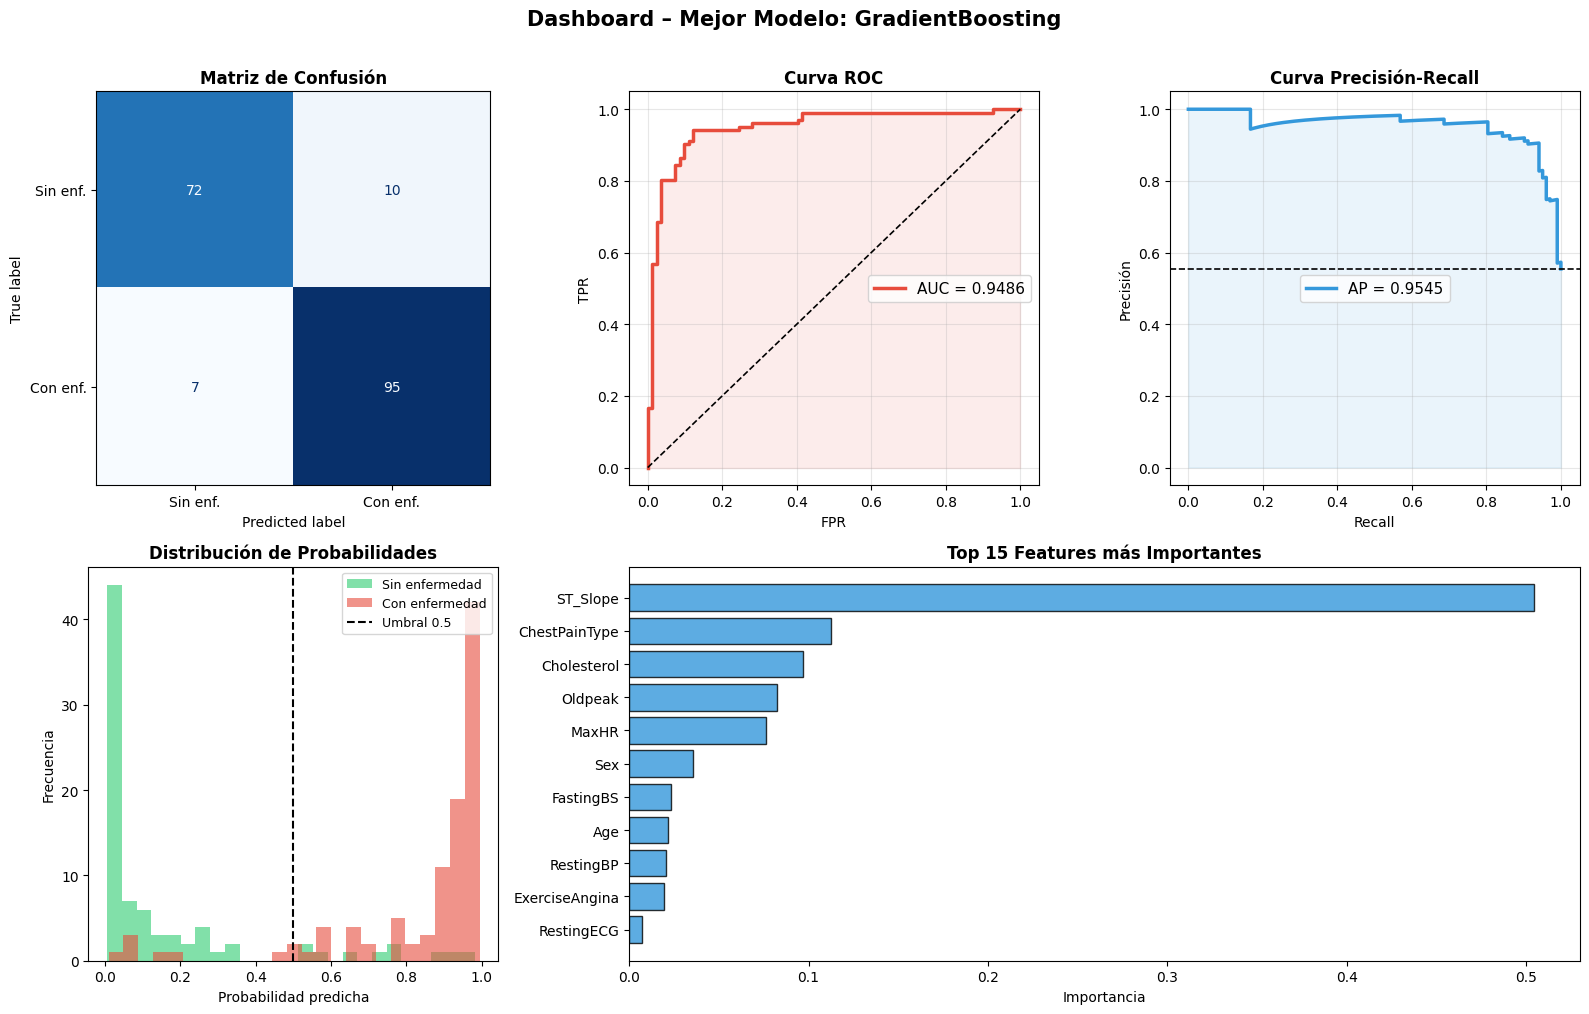

In [102]:
# Dashboard visual del mejor modelo
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig)

# 1. Matriz de confusión
ax1 = fig.add_subplot(gs[0, 0])
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=['Sin enf.','Con enf.'],
    cmap='Blues', colorbar=False, ax=ax1
)
ax1.set_title('Matriz de Confusión', fontsize=12, fontweight='bold')

# 2. Curva ROC
ax2 = fig.add_subplot(gs[0, 1])
fpr, tpr, thresholds = roc_curve(y_test, y_proba_best)
ax2.plot(fpr, tpr, color='#e74c3c', linewidth=2.5,
         label=f'AUC = {auc_best:.4f}')
ax2.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
ax2.plot([0,1],[0,1],'k--', linewidth=1.2)
ax2.set_xlabel('FPR'); ax2.set_ylabel('TPR')
ax2.set_title('Curva ROC', fontsize=12, fontweight='bold')
ax2.legend(fontsize=11); ax2.grid(alpha=0.3)

# 3. Curva Precisión-Recall
ax3 = fig.add_subplot(gs[0, 2])
prec, rec, _ = precision_recall_curve(y_test, y_proba_best)
ap = average_precision_score(y_test, y_proba_best)
ax3.plot(rec, prec, color='#3498db', linewidth=2.5, label=f'AP = {ap:.4f}')
ax3.fill_between(rec, prec, alpha=0.1, color='#3498db')
ax3.axhline(y_test.mean(), color='k', linestyle='--', linewidth=1.2)
ax3.set_xlabel('Recall'); ax3.set_ylabel('Precisión')
ax3.set_title('Curva Precisión-Recall', fontsize=12, fontweight='bold')
ax3.legend(fontsize=11); ax3.grid(alpha=0.3)

# 4. Distribución de probabilidades predichas
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(y_proba_best[y_test==0], bins=25, alpha=0.6,
         color='#2ecc71', label='Sin enfermedad')
ax4.hist(y_proba_best[y_test==1], bins=25, alpha=0.6,
         color='#e74c3c', label='Con enfermedad')
ax4.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Umbral 0.5')
ax4.set_xlabel('Probabilidad predicha'); ax4.set_ylabel('Frecuencia')
ax4.set_title('Distribución de Probabilidades', fontsize=12, fontweight='bold')
ax4.legend(fontsize=9)

# 5. Importancia de features (si el modelo lo soporta)
ax5 = fig.add_subplot(gs[1, 1:])
clf_step = mejor_grid.best_estimator_.named_steps['clf']
if hasattr(clf_step, 'feature_importances_'):
    importancias = clf_step.feature_importances_
    feat_names   = X.columns.tolist()
    idx = np.argsort(importancias)[-15:]  # top 15
    ax5.barh(np.array(feat_names)[idx], importancias[idx],
             color='#3498db', edgecolor='black', alpha=0.8)
    ax5.set_title('Top 15 Features más Importantes', fontsize=12, fontweight='bold')
    ax5.set_xlabel('Importancia')
elif hasattr(clf_step, 'coef_'):
    coefs      = clf_step.coef_[0]
    feat_names = X.columns.tolist()
    idx = np.argsort(np.abs(coefs))[-15:]
    colors_coef = ['#e74c3c' if c > 0 else '#3498db' for c in coefs[idx]]
    ax5.barh(np.array(feat_names)[idx], coefs[idx],
             color=colors_coef, edgecolor='black', alpha=0.8)
    ax5.set_title('Top 15 Coeficientes (rojo=riesgo, azul=protector)',
                  fontsize=12, fontweight='bold')
    ax5.set_xlabel('Coeficiente')
    ax5.axvline(0, color='black', linewidth=1)
else:
    ax5.text(0.5, 0.5, f'{mejor_nombre} no expone\nimportancia de features',
             ha='center', va='center', fontsize=13, transform=ax5.transAxes)
    ax5.set_title('Importancia de Features', fontsize=12, fontweight='bold')

plt.suptitle(f'Dashboard – Mejor Modelo: {mejor_nombre}',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

El modelo Gradient Boosting muestra un excelente desempeño, con una alta capacidad de clasificacion con un  AUC≈0.95 y una curva Precision-Recall consistente. La matriz de confusión indica pocos errores, con buena detección tanto de casos positivos como negativos. La distribución de probabilidades evidencia una clara separación entre clases, lo que facilita la clasificación. Finalmente, variables como ST_Slope, ChestPainType y Cholesterol destacan como las más influyentes en la predicción del modelo.

## 13. Exportación del Mejor Modelo

In [103]:
import joblib
import os

joblib.dump(mejor_grid.best_estimator_, "model.joblib")

print("Guardado en:", os.path.abspath("model.joblib"))

# Verificación
modelo_cargado = joblib.load("model.joblib")
y_check = modelo_cargado.predict(X_test[:10])

print(f'✅ Verificación – primeras 10 predicciones: {y_check.tolist()}')
print(f'   Esperado (real):                         {y_test[:10].tolist()}')

Guardado en: c:\Users\Juanes Garcia Gomez\Downloads\Miniproyecto2\Miniproyecto2\notebooks\model.joblib
✅ Verificación – primeras 10 predicciones: [1, 1, 1, 1, 0, 0, 0, 1, 0, 1]
   Esperado (real):                         [1, 1, 1, 1, 0, 0, 0, 1, 0, 1]


El resultado muestra que el modelo exportado se carga correctamente y genera predicciones coherentes. Las primeras 10 predicciones coinciden exactamente con los valores reales, lo que valida que el proceso de guardado y carga no alteró el comportamiento del modelo. Esto confirma que el modelo está listo para ser utilizado en producción o en una aplicación.